In [1]:
import pandas as pd
df_test = pd.read_csv("https://raw.githubusercontent.com/kup-kup/telemarketing-prediction/refs/heads/main/processed-data/test.csv")
df_train = pd.read_csv("https://raw.githubusercontent.com/kup-kup/telemarketing-prediction/refs/heads/main/processed-data/train.csv")

In [2]:
df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 32950 entries, 0 to 32949
Data columns (total 38 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   age                32950 non-null  float64
 1   education          32950 non-null  float64
 2   campaign           32950 non-null  float64
 3   previous           32950 non-null  float64
 4   cons.conf.idx      32950 non-null  float64
 5   y                  32950 non-null  bool   
 6   marital_married    32950 non-null  bool   
 7   marital_single     32950 non-null  bool   
 8   job_blue-collar    32950 non-null  bool   
 9   job_entrepreneur   32950 non-null  bool   
 10  job_housemaid      32950 non-null  bool   
 11  job_management     32950 non-null  bool   
 12  job_retired        32950 non-null  bool   
 13  job_self-employed  32950 non-null  bool   
 14  job_services       32950 non-null  bool   
 15  job_student        32950 non-null  bool   
 16  job_technician     32950 non-null

In [3]:
df_test.info()

<class 'pandas.DataFrame'>
RangeIndex: 8238 entries, 0 to 8237
Data columns (total 38 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   age                8238 non-null   float64
 1   education          8238 non-null   float64
 2   campaign           8238 non-null   float64
 3   previous           8238 non-null   float64
 4   cons.conf.idx      8238 non-null   float64
 5   y                  8238 non-null   bool   
 6   marital_married    8238 non-null   bool   
 7   marital_single     8238 non-null   bool   
 8   job_blue-collar    8238 non-null   bool   
 9   job_entrepreneur   8238 non-null   bool   
 10  job_housemaid      8238 non-null   bool   
 11  job_management     8238 non-null   bool   
 12  job_retired        8238 non-null   bool   
 13  job_self-employed  8238 non-null   bool   
 14  job_services       8238 non-null   bool   
 15  job_student        8238 non-null   bool   
 16  job_technician     8238 non-null   

In [4]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

X_train = df_train.drop('y', axis=1)
y_train = df_train['y']

X_test = df_test.drop('y', axis=1)
y_test = df_test['y']

# Ensure X_test columns match X_train columns in order
X_test = X_test[X_train.columns]

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'
)

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}\n")
print("--- Classification Report ---")
print(classification_report(y_test, y_pred))
print("--- Confusion Matrix ---")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.8946

--- Classification Report ---
              precision    recall  f1-score   support

       False       0.91      0.97      0.94      7310
        True       0.57      0.27      0.36       928

    accuracy                           0.89      8238
   macro avg       0.74      0.62      0.65      8238
weighted avg       0.87      0.89      0.88      8238

--- Confusion Matrix ---
[[7122  188]
 [ 680  248]]


In [5]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf_base = RandomForestClassifier(random_state=42, class_weight='balanced')

# GridSearchCV
grid_search = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    cv=5,
    n_jobs=-1,
    scoring='f1'
)

grid_search.fit(X_train, y_train)

print("\nbest parameters:")
print(grid_search.best_params_)

# Best Model
best_rf_model = grid_search.best_estimator_
y_pred_tuned = best_rf_model.predict(X_test)

print("\n--- After Tuning ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_tuned):.4f}\n")
print(classification_report(y_test, y_pred_tuned))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_tuned))


best parameters:
{'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}

--- After Tuning ---
Accuracy: 0.8853

              precision    recall  f1-score   support

       False       0.94      0.93      0.93      7310
        True       0.49      0.56      0.53       928

    accuracy                           0.89      8238
   macro avg       0.72      0.75      0.73      8238
weighted avg       0.89      0.89      0.89      8238

Confusion Matrix:
[[6769  541]
 [ 404  524]]


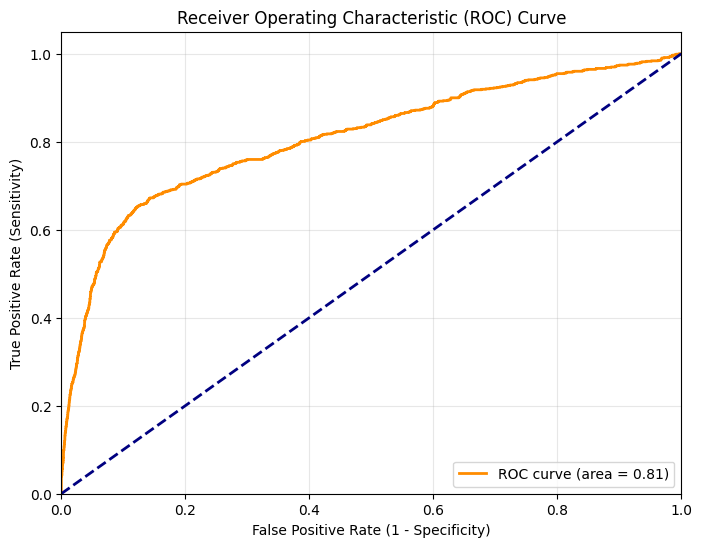

In [6]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

y_probs = best_rf_model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

# Export Model


In [ ]:
import json
import joblib

model_path = "model/rf_model.joblib"
meta_path = "model/rf_meta.json"

# Save fitted model
joblib.dump(best_rf_model, model_path)

# Save metadata for inference
meta = {
    "feature_names": X_train.columns.tolist(),
}
with open(meta_path, "w", encoding="utf-8") as f:
    json.dump(meta, f, indent=2)
